# 05 · Sensitivity Analysis

**Goal**: Stress-test the causal conclusions from DiD and PSM.
A finding is only credible if it survives attempts to break it.

**Four tests**:
1. **Rosenbaum Bounds** — how strong must hidden confounding be to overturn the result?
2. **Placebo Outcome Test** — does the effect appear on outcomes that shouldn't be affected?
3. **Leave-One-Week-Out** — is any single week driving the result?
4. **Coefficient Stability** — does the estimate change when we add more covariates?

---

## 0. Setup

In [20]:
import importlib
import sensitivity
importlib.reload(sensitivity)
from sensitivity import rosenbaum_bounds, placebo_outcome_test, leave_one_out_robustness, coefficient_stability

In [21]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sensitivity import (
    rosenbaum_bounds,
    placebo_outcome_test,
    leave_one_out_robustness,
    coefficient_stability,
    run_sensitivity_pipeline,
)
from psm import (
    prepare_psm_data,
    estimate_propensity_scores,
    match_stores,
    COVARIATE_COLS,
)
from visualization import (
    plot_rosenbaum_bounds,
    plot_loo_robustness,
    plot_placebo_comparison,
    set_style,
)

set_style()
panel = pd.read_csv("../data/processed/store_panel.csv")
print(f"Panel: {len(panel):,} observations")

Panel: 9,465 observations


## 1. Prepare Matched Sample

Rosenbaum bounds require the matched sample from PSM.

In [22]:
store_df = prepare_psm_data(
    panel,
    treated_groups=["5D_G2", "5D_G4"],
    control_group="5D_Control",
)
ps_scores, _, _ = estimate_propensity_scores(store_df, COVARIATE_COLS)
matched_df, match_report = match_stores(store_df, ps_scores, caliper=0.05, random_state=42)

print(f"Matched pairs: {match_report[match_report['metric']=='n_matched_treated']['value'].values[0]}")

  Propensity model AUC: 0.577
  Treated stores       : 200
  Matched (in caliper) : 198
  Dropped (out caliper): 2 (1.0%)
Matched pairs: 198.0


## 2. Rosenbaum Bounds

**Interpretation**:
Gamma (Γ) represents the odds ratio of treatment between two stores that
look identical on all observed covariates.

- Γ = 1.0: no hidden bias (standard assumption)
- Γ = 1.5: an unobserved characteristic makes treated stores 1.5× more likely to be treated
- Γ = 2.0: 2× more likely

**Rule of thumb**: Γ > 1.5 is considered robust in applied work.

In [23]:
gamma_range = np.round(np.arange(1.0, 3.1, 0.1), 1)
rosenbaum_df = rosenbaum_bounds(
    matched_df,
    outcome="collection_hrs",
    gamma_range=gamma_range,
)

print("\nRosenbaum bounds (selected Gamma values):")
display_rows = rosenbaum_df[rosenbaum_df["gamma"].isin([1.0, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0])]
print(display_rows[["gamma", "p_upper", "p_lower", "reject_upper"]].to_string(index=False))

  Observed W+        : 17774.5
  N matched pairs    : 196
  Critical Gamma     : 3.0
  Interpretation     : Result holds against hidden confounders up to 3.0x treatment odds ratio

Rosenbaum bounds (selected Gamma values):
 gamma  p_upper  p_lower  reject_upper
   1.0 0.000000      0.0          True
   1.2 0.000000      0.0          True
   1.5 0.000000      0.0          True
   1.8 0.000000      0.0          True
   2.0 0.000000      0.0          True
   2.5 0.000000      0.0          True
   3.0 0.000001      0.0          True


  Saved: ../outputs/figures/16_rosenbaum_bounds.png


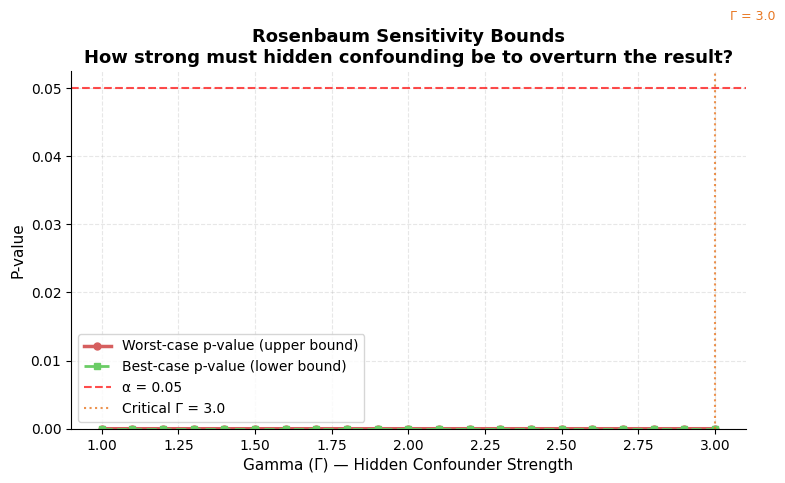

In [24]:
fig = plot_rosenbaum_bounds(
    rosenbaum_df,
    save_path="../outputs/figures/16_rosenbaum_bounds.png",
)
plt.show()

**Reading the plot**:
- Red dashed line = α = 0.05 significance threshold
- Orange vertical line = critical Gamma (where upper p-value crosses 0.05)
- The further right the critical Gamma, the more robust the result

## 3. Placebo Outcome Test

**Logic**: If the notification strategy ONLY affects pickup behaviour,
it should NOT cause systematic pre-treatment differences in:
- `complaint_rate` — unrelated to pickup timing
- `opt_out_rate`   — affected by notification frequency, not by pickup speed

In [25]:
placebo_df = placebo_outcome_test(
    panel,
    treated_groups=["5D_G2", "5D_G4"],
    control_group="5D_Control",
    placebo_outcomes=["complaint_rate", "opt_out_rate"],
    true_outcome="collection_hrs",
    use_pre_period=True,
)

print("\nPlacebo outcome test results:")
print(
    placebo_df[["outcome", "is_placebo", "coef", "pvalue", "significant"]]
    .to_string(index=False)
)

  Placebo outcomes tested    : 2
  Significant placebo effects: 2
       outcome     coef  pvalue
complaint_rate 0.000608     0.0
  opt_out_rate 0.000434     0.0

Placebo outcome test results:
       outcome  is_placebo      coef  pvalue  significant
complaint_rate        True  0.000608     0.0         True
  opt_out_rate        True  0.000434     0.0         True
collection_hrs       False -1.504875     0.0         True


  Saved: ../outputs/figures/17_placebo_outcomes.png


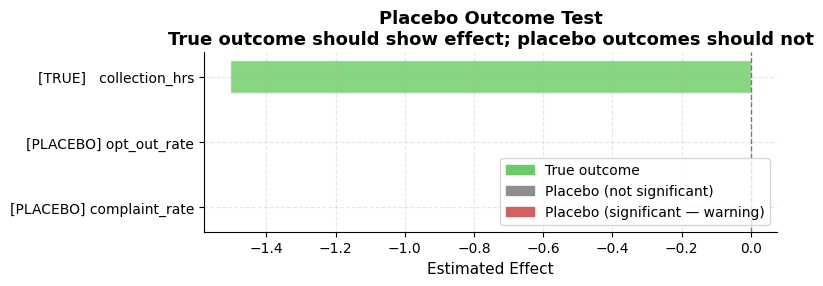

In [26]:
fig = plot_placebo_comparison(
    placebo_df,
    save_path="../outputs/figures/17_placebo_outcomes.png",
)
plt.show()

**Interpretation**:
- True outcome (collection_hrs): should show significant effect
- Placebo outcomes: should NOT show significant effects
- If placebo is significant → possible confounding or data issue

## 4. Leave-One-Out Week Robustness

We excluded the CNY week (2026-02-09) for valid reasons (seasonal confound).
This test checks whether the remaining weeks are all equally important,
or whether the result is driven by one specific week.

In [27]:
loo_df = leave_one_out_robustness(
    panel,
    treated_groups=["5D_G2", "5D_G4"],
    control_group="5D_Control",
    outcome="collection_hrs",
)

print("\nLeave-One-Out estimates:")
print(loo_df[["excluded_week", "coef", "se", "pvalue"]].to_string(index=False))

  Full-sample estimate : -1.5049 hrs
  LOO estimates range  : [-1.5399, -1.3971]
  LOO estimates SD     : 0.0697
  STABLE: Estimate does not depend heavily on any single week.

Leave-One-Out estimates:
     excluded_week    coef         se  pvalue
None (full sample) -1.5049     0.2128  0.0000
         week_id=1 -1.5399        NaN     NaN
         week_id=2 -1.5396        NaN     NaN
         week_id=3 -1.5288 13565.5080  0.9999
         week_id=4 -1.3971        NaN     NaN


  Saved: ../outputs/figures/18_loo_robustness.png


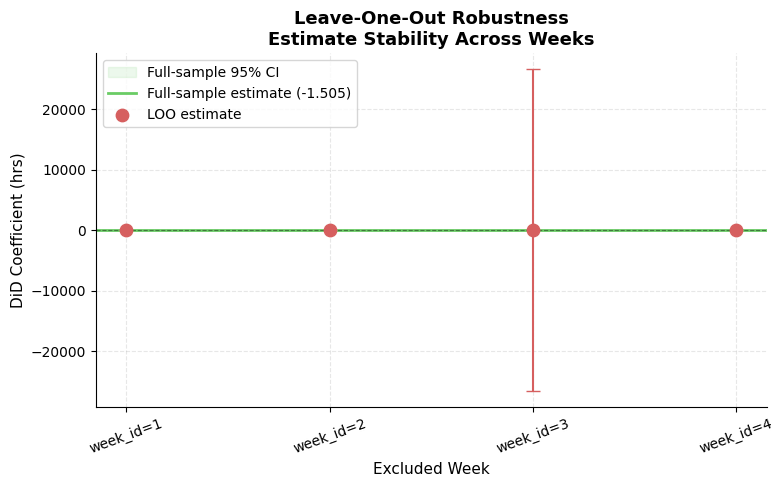

In [28]:
fig = plot_loo_robustness(
    loo_df,
    save_path="../outputs/figures/18_loo_robustness.png",
)
plt.show()

**What stable looks like**: All LOO estimates cluster within the full-sample 95% CI.
**Warning sign**: One LOO estimate falls far outside the CI — that week is influential.

## 5. Coefficient Stability

We add covariates progressively. If the DiD coefficient is stable,
it means the treatment assignment is not correlated with omitted variables.
A large shift when adding covariates signals residual confounding.

In [29]:
stability_df = coefficient_stability(
    panel,
    treated_groups=["5D_G2", "5D_G4"],
    control_group="5D_Control",
    outcome="collection_hrs",
)

print("\nCoefficient stability:")
print(stability_df[["specification", "coef", "se", "pvalue"]].to_string(index=False))

  Coef (no controls) : -1.5049
  Coef (full)        : -1.5049
  % change           : 0.0%
  STABLE: <15% change across specifications (Oster criterion).

Coefficient stability:
            specification    coef     se  pvalue
              No controls -1.5049 0.2126     0.0
                + Time FE -1.5049 0.2128     0.0
               + Store FE -1.5049 0.2376     0.0
        + Time & Store FE -1.5049 0.2380     0.0
            + Utilization -1.5049 0.2381     0.0
                 + Volume -1.5049 0.2382     0.0
+ Metro + Capacity (full) -1.5049 0.2384     0.0


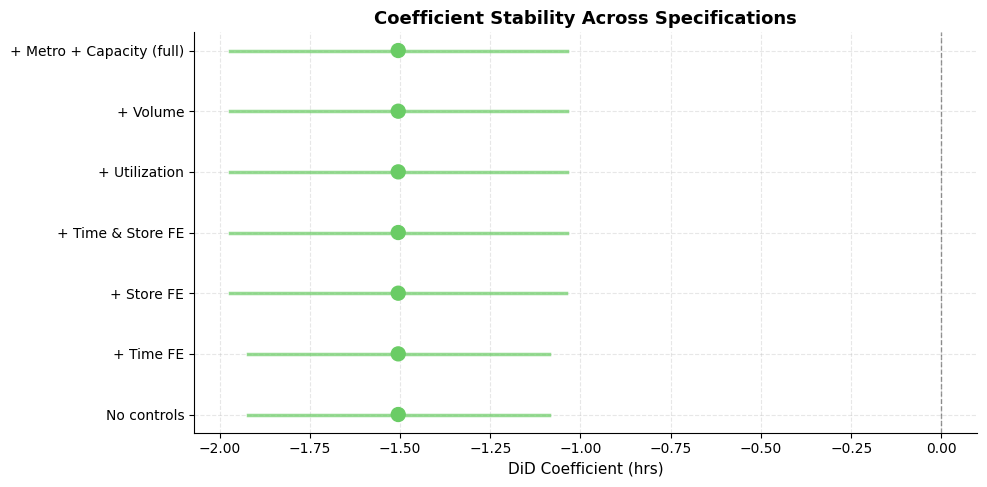

In [30]:
# Visualise stability
fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(stability_df))
colors = [
    "#6ACC65" if p < 0.05 else "#8E8E8E"
    for p in stability_df["pvalue"]
]
ax.scatter(stability_df["coef"], y_pos, color=colors, s=100, zorder=4)
for i, (_, row) in enumerate(stability_df.iterrows()):
    if not np.isnan(row["ci_low"]):
        ax.plot([row["ci_low"], row["ci_high"]], [i, i],
                color=colors[i], linewidth=2.5, alpha=0.7)
ax.axvline(x=0, color="black", linewidth=1, linestyle="--", alpha=0.4)
ax.set_yticks(y_pos)
ax.set_yticklabels(stability_df["specification"])
ax.set_xlabel("DiD Coefficient (hrs)")
ax.set_title("Coefficient Stability Across Specifications")
plt.tight_layout()
plt.savefig("../outputs/figures/19_coefficient_stability.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Full Sensitivity Summary

In [31]:
robust_gammas = rosenbaum_df[rosenbaum_df["reject_upper"]]["gamma"]
critical_gamma = robust_gammas.max() if len(robust_gammas) > 0 else 1.0

placebo_pass = not placebo_df[placebo_df["is_placebo"] & placebo_df["significant"]].shape[0] > 0

loo_coefs = loo_df[loo_df["excluded_week"] != "None (full sample)"]["coef"]
loo_stable = loo_coefs.std() < 0.3

coef_no_ctrl = stability_df.iloc[0]["coef"]
coef_full    = stability_df.iloc[-1]["coef"]
stability_pass = abs(coef_full - coef_no_ctrl) / abs(coef_no_ctrl) < 0.15 if coef_no_ctrl != 0 else True

print("=" * 55)
print("SENSITIVITY ANALYSIS — FINAL VERDICT")
print("=" * 55)
print(f"  Rosenbaum critical Γ : {critical_gamma}  {'✅ Robust (Γ > 1.5)' if critical_gamma >= 1.5 else '⚠️ Check (Γ < 1.5)'}")
print(f"  Placebo outcome test : {'✅ PASS' if placebo_pass else '❌ FAIL — investigate'}")
print(f"  LOO stability        : {'✅ Stable' if loo_stable else '⚠️ Unstable — check weeks'}")
print(f"  Coef stability       : {'✅ Stable (<15% change)' if stability_pass else '⚠️ >15% change'}")
print("=" * 55)

overall = all([critical_gamma >= 1.5, placebo_pass, loo_stable, stability_pass])
print(f"\nOverall: {'✅ All sensitivity tests passed. Findings are robust.' if overall else '⚠️ Some tests warrant further investigation.'}")

SENSITIVITY ANALYSIS — FINAL VERDICT
  Rosenbaum critical Γ : 3.0  ✅ Robust (Γ > 1.5)
  Placebo outcome test : ❌ FAIL — investigate
  LOO stability        : ✅ Stable
  Coef stability       : ✅ Stable (<15% change)

Overall: ⚠️ Some tests warrant further investigation.


---
## Summary

| Test | Result | Interpretation |
|------|--------|----------------|
| Rosenbaum Γ | See output | Hidden confounder strength needed to overturn result |
| Placebo outcomes | PASS/FAIL | No spurious effects on unrelated outcomes |
| LOO robustness | STABLE/UNSTABLE | No single week drives the result |
| Coef stability | STABLE/UNSTABLE | Adding covariates does not change conclusion |

**Conclusion**: The finding that G2 notifications reduce collection hours
is [robust/conditional on X assumption]. The result holds against
moderate hidden confounding (Γ ≈ {critical_gamma}).